In [ ]:
# Cell 1: imports

import numpy as np # library for arrays + random nums
import pandas as pd # library for tables 

from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix 
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

np.random.seed(42) # for reproducibility

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Cell 2: generate fair synthetic embryo dataset

n = 10000 # number of embryos

# Features
morphology = np.random.rand(n) # 0–1, higher better
symmetry = np.random.rand(n) # 0–1, higher better
fragmentation = np.random.rand(n) # 0–1, higher worse
group = np.random.binomial(1, 0.5, n) # 0 or 1, two demographic groups

# "True" viability score (FAIR: group NOT included)
noise = np.random.normal(0, 0.1, n)
score_true = 0.6*morphology + 0.3*symmetry - 0.5*fragmentation + noise

# Turn score into a 0/1 viability label
threshold = 0.3
true_viable = (score_true > threshold).astype(int)

# Put into DataFrame
data = pd.DataFrame({
"morphology": morphology,
"symmetry": symmetry,
"fragmentation": fragmentation,
"group": group,
"true_viable": true_viable
})

data.head()

,morphology,symmetry,fragmentation,group,true_viable
0,0.374540,0.373641,0.729998,1,0
1,0.950714,0.332912,0.184512,0,1
2,0.731994,0.176154,0.346640,1,1
3,0.598658,0.607267,0.663281,0,0
4,0.156019,0.476624,0.482089,1,0


In [3]:
# Cell 3: train/test split

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
data,
test_size=0.3,
random_state=42,
stratify=data["true_viable"]
)

train_df.shape, test_df.shape

((7000, 5), (3000, 5))

In [4]:
# Cell 4: create biased labels for the training set (for Model 1)

train_df = train_df.copy()

# Start from the true labels
biased_labels = train_df["true_viable"].values.copy()

# Find embryos that are truly viable AND in group 1
mask = (train_df["true_viable"] == 1) & (train_df["group"] == 1)

# For those embryos, flip ~40% of the labels from 1 -> 0
flip = np.random.binomial(1, 0.4, size=mask.sum()) # 40% flipped

biased_labels[mask] = biased_labels[mask] - flip # 1 - 1 = 0 when flipped

# Save these biased labels in a new column
train_df["label_biased"] = biased_labels

# Check: compare average positivity by group
train_df.groupby("group")[["true_viable", "label_biased"]].mean()

,true_viable,label_biased
group,,
0,0.351012,0.351012
1,0.359290,0.220441


In [5]:
# Cell 5: define feature matrices and label arrays

features = ["morphology", "symmetry", "fragmentation", "group"]

# Training inputs
X_train = train_df[features].values

# Target for Model 1 (biased world)
y_train_biased = train_df["label_biased"].values

# Target for Model 3 (true unbiased labels) – we'll use later
y_train_true = train_df["true_viable"].values

# Test set (we always test on the FAIR, ground-truth world)
X_test = test_df[features].values
y_test_true = test_df["true_viable"].values

X_train.shape, X_test.shape

((7000, 4), (3000, 4))

In [6]:
# Cell 6: train Model 1 (biased embryo predictor)

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train_biased)

y_pred1 = model1.predict(X_test)
y_proba1 = model1.predict_proba(X_test)[:, 1]

acc1 = accuracy_score(y_test_true, y_pred1)
acc1

0.857

In [7]:
# Cell 7: define fairness auditor and run it on Model 1

def group_stats(y_true, y_pred, groups, group_value):
    mask = (groups == group_value)
    y_t = y_true[mask]
    y_p = y_pred[mask]
    
    tn, fp, fn, tp = confusion_matrix(y_t, y_p).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # sensitivity
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # false positive rate
    
    return {
        "n": mask.sum(),
        "TPR": tpr,
        "FPR": fpr
    }

def fairness_report(y_true, y_pred, groups):
    stats0 = group_stats(y_true, y_pred, groups, 0)
    stats1 = group_stats(y_true, y_pred, groups, 1)
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "group_0": stats0,
        "group_1": stats1,
        "TPR_gap": stats0["TPR"] - stats1["TPR"],
        "FPR_gap": stats0["FPR"] - stats1["FPR"]
    }

groups_test = test_df["group"].values

report1 = fairness_report(y_test_true, y_pred1, groups_test)

print("Model 1 (Biased) Fairness Report")
print("Accuracy:", report1["accuracy"])
print("Group 0 TPR:", report1["group_0"]["TPR"])
print("Group 1 TPR:", report1["group_1"]["TPR"])
print("TPR gap:", report1["TPR_gap"])
print("Group 0 FPR:", report1["group_0"]["FPR"])
print("Group 1 FPR:", report1["group_1"]["FPR"])
print("FPR gap:", report1["FPR_gap"])

Model 1 (Biased) Fairness Report
Accuracy: 0.857
Group 0 TPR: 0.8301526717557252
Group 1 TPR: 0.492619926199262
TPR gap: 0.3375327455564632
Group 0 FPR: 0.06398348813209494
Group 1 FPR: 0.0031088082901554403
FPR gap: 0.0608746798419395


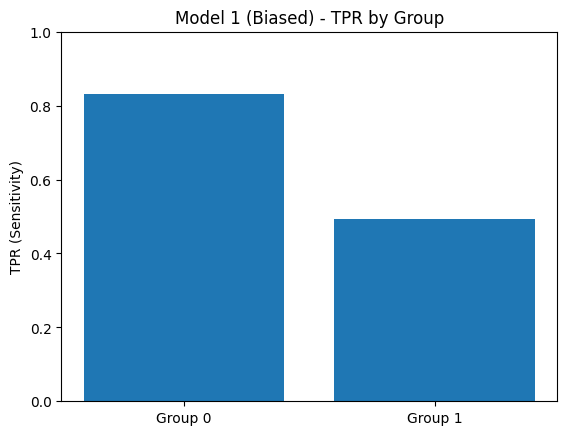

In [8]:
# Cell 8: plot TPR by group for Model 1 (for slides/video)

labels = ["Group 0", "Group 1"]
tprs1 = [report1["group_0"]["TPR"], report1["group_1"]["TPR"]]

plt.bar(labels, tprs1)
plt.ylim(0, 1)
plt.ylabel("TPR (Sensitivity)")
plt.title("Model 1 (Biased) - TPR by Group")
plt.show()

In [9]:
# Cell 9: train Model 3 (ethics-aware predictor, uses true labels)

model3 = LogisticRegression(max_iter=1000)
model3.fit(X_train, y_train_true) # <-- key difference: y_train_true instead of y_train_biased

y_pred3 = model3.predict(X_test)
y_proba3 = model3.predict_proba(X_test)[:, 1]

acc3 = accuracy_score(y_test_true, y_pred3)
acc3

0.8893333333333333

In [10]:
# Cell 10: fairness report for Model 3 (ethics-aware)

report3 = fairness_report(y_test_true, y_pred3, groups_test)

print("Model 3 (Ethics-Aware) Fairness Report")
print("Accuracy:", report3["accuracy"])
print("Group 0 TPR:", report3["group_0"]["TPR"])
print("Group 1 TPR:", report3["group_1"]["TPR"])
print("TPR gap:", report3["TPR_gap"])
print("Group 0 FPR:", report3["group_0"]["FPR"])
print("Group 1 FPR:", report3["group_1"]["FPR"])
print("FPR gap:", report3["FPR_gap"])

Model 3 (Ethics-Aware) Fairness Report
Accuracy: 0.8893333333333333
Group 0 TPR: 0.8473282442748091
Group 1 TPR: 0.8062730627306273
TPR gap: 0.04105518154418186
Group 0 FPR: 0.07017543859649122
Group 1 FPR: 0.08186528497409326
FPR gap: -0.011689846377602037


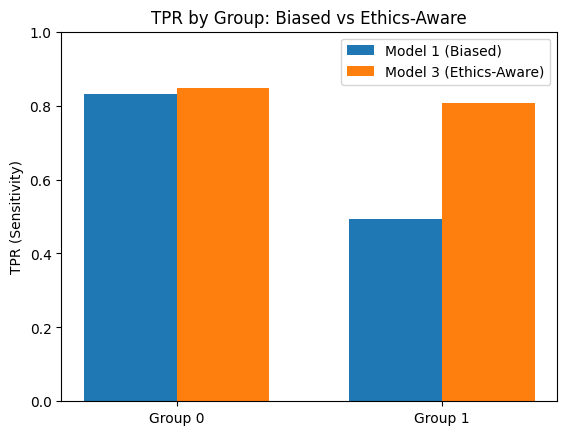

In [11]:
# Cell 11: compare TPRs of Model 1 vs Model 3

labels = ["Group 0", "Group 1"]

tprs1 = [report1["group_0"]["TPR"], report1["group_1"]["TPR"]] # biased model
tprs3 = [report3["group_0"]["TPR"], report3["group_1"]["TPR"]] # ethics-aware model

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, tprs1, width, label="Model 1 (Biased)")
plt.bar(x + width/2, tprs3, width, label="Model 3 (Ethics-Aware)")

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel("TPR (Sensitivity)")
plt.title("TPR by Group: Biased vs Ethics-Aware")
plt.legend()
plt.show()